# <span style="color:#336699">BDC-Agri: using temperature data for calculating Growing degree days (GDD)</span>
<hr style="border:2px solid #0077b9;">

<div style="text-align: left;">
    <a href="https://nbviewer.jupyter.org/github/brazil-data-cube/code-gallery/"><img src="https://raw.githubusercontent.com/jupyter/design/master/logos/Badges/nbviewer_badge.svg" align="center"/></a>
</div>

<br/>

<div style="text-align: center;font-size: 90%;">
    Gabriel Sansigolo<sup><a href="https://orcid.org/0000-0003-0789-5858"><i class="fab fa-lg fa-orcid" style="color: #a6ce39"></i></a></sup>
    <br/><br/>
    Earth Observation and Geoinformatics Division, National Institute for Space Research (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Contact: <a href="mailto:gabriel.sansigolo@inpe.br">gabriel.sansigolo@inpe.br</a>
    <br/><br/>
    Last Update: Oct 5, 2026
</div>

<br/>

<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;">
<b>Abstract.</b> This Jupyter Notebook gives an overview on how to use the BDC-Agri's FWeather to create creating <em>multidimensional arrays</em> from satellite imagery and calculating Growing degree days (GDD). 
</div>

<br/>
<div style="text-align: justify;  margin-left: 25%; margin-right: 25%;font-size: 75%; border-style: solid; border-color: #0077b9; border-width: 1px; padding: 5px;">
    <b>This Jupyter Notebook is a supplement to the following paper:</b>
    <div style="margin-left: 10px; margin-right: 10px">
    Sansigolo, G.; Nogueira, S. M. C.; Giarolla, A. Ferreira, K. R.; Queiroz, G. R.; Adami, M.<a href="http://www.google.com" target="_blank">Construindo uma plataforma aberta para monitoramento agrícola em larga escala
    </div>
</div>

# Introduction
<hr style="border:1px solid #0077b9;">

The **fweather** is an open-source Python package for meteorological time series analysis. It used the SpatioTemporal Asset Catalog (STAC) to access meteorological data and retrieve it as virtual data cubes, facilitating the retrieval of time series.

It provides methods of building a data cube and retrieving time series of cumulative precipitation, daily precipitation, temperature and climate change projections.

With the package, it’s possible to perform large-scale agriculture monitoring using weather time series with no need to download data locally and programming skills. The proposed tool was developed as a component of the Brazil Data Cube (BDC) platform.

FWeather client features two main functions:

- ``data_cube()``: Function that allow the researcher to define the desired data cube, with it the fweather build a virtual data cube of precipitation, temperature, or climate change projection data for the desired region.

- ``get_timeseries()``: Function that works by allowing the researcher to extract meteorological time series for a point (latitude and longitude).

This Jupyter Notebook shows how to use smosaics in Python with Brazil Data Cube data.

## Operations
<hr style="border:1px solid #0077b9;">

The ``data_cube()`` and ``get_timeseries()`` functions of the fweather package follow the same workflow, illustrated by the cascade structure on the right side (Figure 1).

<div align="center">
    <figcaption><strong>Figure 1</strong> - Workflow of the meteorological time series analyses tool. </figcaption>
    <img src="../src/images/fweather_full.png" align="center" width="768"/>
    <br>
</div>

Module (a), the Python client component, includes layers for schema the data cube, discovery the data from the collection, access the data set and stacking the data set into a data cube. The outputs of this client are xarray of the meteorological data and JSON file of the meteorological time series.

In [1]:
!pip install git+https://github.com/GSansigolo/fweather.git

  Cloning https://github.com/GSansigolo/fweather.git to /tmp/pip-req-build-bj41sgxb
  Running command git clone --filter=blob:none --quiet https://github.com/GSansigolo/fweather.git /tmp/pip-req-build-bj41sgxb
  Resolved https://github.com/GSansigolo/fweather.git to commit 9937965dc1bffa1a202d08913a4a0bde5cb8f035
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached urllib3-2.2.2-py3-none-any.whl.metadata (6.4 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
Using cached urllib3-2.2.2-py3-none-any.whl (121 kB)
Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
  Attempting uninstall: urllib3
    Found existing installation: urll

In [2]:
!pip install wcpms

  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached requests-2.33.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached pandas-2.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached pandas-2.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.0 MB)
Using cached requests-2.33.0-py3-none-any.whl (65 kB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.2.2
    Uninstalling urllib3-2.2.2:
      Successfully uninstalled urllib3-2.2.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
  Attempting uninstall: requests━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install --upgrade pandas pyarrow

  Using cached pandas-3.0.6-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.6-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.1 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fweather 0.5.2 requires requests==2.32.3, but you have requests 2.33.0 which is incompatible.
fweather 0.5.2 requires scipy>=1.15.0, but you have scipy 1.13.1 which is incompatible.
fweather 0.5.2 requires urllib3==2.2.2, but you have urllib3 2.7.0 which is incompatible.
wcpms 0.4.2 requires pandas==2.2.2, but you have pandas 3.0.6 which is incompatible.
simplecube 0.9.2 requires pandas==2.2.2, but you have pandas 3.0.6 which is incompatible.
simplecube 0.9.2 requires

In [4]:
from fweather import data_cube
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd
import numpy as np

# Open CONAB's shapefile of soy crop Rio Grande do Sul 2024-2025
<hr style="border:1px solid #0077b9;">

In [ ]:
file_path = "../data/raw/soja_RS_24_25_mini.zip"

bbox = (-54.1585, -31.8788, -53.5868, -31.2459)

df = gpd.read_file(file_path, bbox=bbox)

In [6]:
def generate_points_in_geometry(geometry, n_points):
    points = []
    min_x, min_y, max_x, max_y = geometry.bounds

    while len(points) < n_points:
        random_points = [
            Point(np.random.uniform(min_x, max_x), np.random.uniform(min_y, max_y))
            for _ in range(n_points - len(points))
        ]

        valid_points = [p for p in random_points if geometry.contains(p)]
        points.extend(valid_points)

    if len(points) > 1:
        return points
    else:
        return points[0]


# Calculates points of corn crop 2nd harvest within the geometry.
<hr style="border:1px solid #0077b9;">

In [7]:
n = 1
points = df['geometry'].apply(lambda geom: generate_points_in_geometry(geom, n))

In [8]:
points = points.sample(n=1500, random_state=42)
points = points.reset_index(drop=True)

In [9]:
points.tail()

1495    POINT (-54.13658 -31.48269)
1496    POINT (-53.76808 -31.82643)
1497    POINT (-53.90342 -31.64746)
1498    POINT (-53.80242 -31.61449)
1499    POINT (-53.93394 -31.51248)
Name: geometry, dtype: geometry

<Axes: >

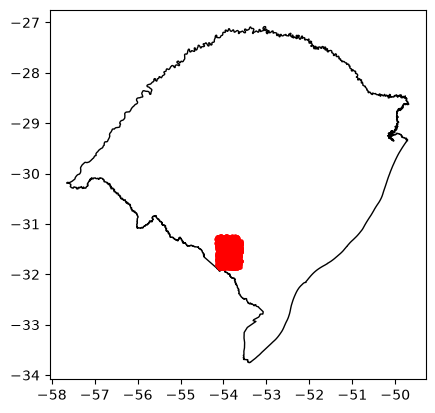

In [ ]:
file_path = "../data/raw/BR_UF_2024.zip"

uf_df = gpd.read_file(file_path)

rs_shape = uf_df[uf_df['SIGLA_UF'] == 'RS']

base = rs_shape.plot(color='white', edgecolor='black')
points.plot(ax=base, marker='o', color='red', markersize=5)

# Open IBGE's shapefile of Rio Grande do Sul State
<hr style="border:1px solid #0077b9;">

In [11]:
def calculate_extent(file):
    bounds = file.total_bounds
    return bounds

In [12]:
extent = calculate_extent(rs_shape)

You should create a `stac_url` python variable attached to a given service:

In [13]:
stac_url = "https://data.inpe.br/bdc/stac/v1"

# Creating a temperature data cube based on SAMET Daily data
<hr style="border:1px solid #0077b9;">

To creating a temperature data cube based on SAMET Daily data from `January 1st, 2024` to `December 31st, 2024`, use the `data_cube()` function. Set the `collection` parameter to `samet_daily-1` to the retrive the SAMET Daily data from BIG catalog, and the `bands` to `tmean`.

In [14]:
samet_temp_cube=data_cube(
    stac_url=stac_url,
    collection="samet_daily-1",
    start_date="2025-01-01",
    end_date="2025-09-30",
    bbox=",".join(map(str, extent)),
    bands=["tmean"]
)

samet_temp_cube

Fetching... : 100%|██████████| 273/273 [01:27<00:00,  3.12 scenes/s]


<xarray.Dataset> Size: 47MB
Dimensions:  (lon: 159, lat: 134, time: 273)
Coordinates:
  * lon      (lon) float64 1kB -57.6 -57.55 -57.5 -57.45 ... -49.8 -49.75 -49.7
  * lat      (lat) float64 1kB -33.75 -33.7 -33.65 -33.6 ... -27.2 -27.15 -27.1
  * time     (time) datetime64[ns] 2kB 2025-01-01 2025-01-02 ... 2025-09-30
Data variables:
    tmed     (time, lat, lon) float64 47MB 25.56 25.46 25.2 ... 18.66 18.39

# Retrieve the time series from the SAMET data cube for each of the points.
<hr style="border:1px solid #0077b9;">

In [15]:
time_series_arrays = []

for location in points.geometry:

    point_lon = location.x
    point_lat = location.y

    ts = samet_temp_cube['tmed'].sel(lon=point_lon, lat=point_lat, method='nearest')

    time_series_arrays.append(ts.values)

In [16]:
df_results = pd.DataFrame({
    'geometry': points,
    'ts': time_series_arrays
})

df_results.tail()

,geometry,ts
1495,POINT (-54.13658 -31.48269),"[25.978191375732422, 26.866222381591797, 22.39..."
1496,POINT (-53.76808 -31.82643),"[25.21140480041504, 25.959131240844727, 21.611..."
1497,POINT (-53.90342 -31.64746),"[25.72007942199707, 26.587993621826172, 22.095..."
1498,POINT (-53.80242 -31.61449),"[25.67599868774414, 26.549488067626953, 22.099..."
1499,POINT (-53.93394 -31.51248),"[25.87614631652832, 26.766666412353516, 22.220..."


# Retrieves phenological metrics for each of the points.
<hr style="border:1px solid #0077b9;">



In [17]:
from simplecube import simple_cube, get_timeseries_datacube

S2_cube=simple_cube(
    stac_url=stac_url,
    collection="S2-16D-2",
    start_date="2025-01-01",
    end_date="2025-09-30",
    bbox="-54.1585,-31.8788,-53.5868,-31.2459",
    bands=["NDVI"]
)

S2_cube

Fetching... : 100%|██████████| 36/36 [00:00<00:00, 119.32 scenes/s]


<xarray.Dataset> Size: 1GB
Dimensions:      (band: 1, x: 5699, y: 6696, time: 18)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 46kB 4.984e+06 4.984e+06 ... 5.041e+06 5.041e+06
  * y            (y) float64 54kB 7.877e+06 7.877e+06 ... 7.811e+06 7.811e+06
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 144B 2025-01-01 2025-01-17 ... 2025-09-30
Data variables:
    ndvi         (time, band, y, x) int16 1GB 7200 7234 7107 ... 9187 9222 9302

In [18]:
import rasterio

sos_path = "phenometrics/S2-10D_V1_000_phenological_metrics_SOS_TIME.tif"
eos_path = "phenometrics/S2-10D_V1_000_phenological_metrics_EOS_TIME.tif"

def get_local_pheno_metrics(point_lat, point_lon):
    
    with rasterio.open(sos_path) as src_sos:
        sos_val = next(src_sos.sample([(point_lon, point_lat)]))[0]
        
    with rasterio.open(eos_path) as src_eos:
        eos_val = next(src_eos.sample([(point_lon, point_lat)]))[0]

    return {
        "sos_t": int(sos_val),
        "eos_t": int(eos_val)
    }

In [19]:
from datetime import datetime

def calculate_days_distance(target_date_str, start_date_str="01-01-2025"):
    clean_target = str(target_date_str)
    clean_target = clean_target.strip("[]'\" ")
    if clean_target.endswith('Z'):
        clean_target = clean_target.replace('Z', '+00:00')
    start_date = datetime.strptime(start_date_str, "%d-%m-%Y")
    target_date = datetime.fromisoformat(clean_target)
    target_date = target_date.replace(tzinfo=None)
    distance = target_date - start_date
    return distance.days


In [20]:
from datetime import datetime, timedelta

def add_days(date, days):
    if isinstance(date, str):
        date = datetime.strptime(date, "%Y-%m-%d")

    return date + timedelta(days=days)

In [21]:
import tqdm

sos_array = []
eos_array = []
ndvi_array = []


for location in tqdm.tqdm(points.geometry, desc='Fetching... ', unit=" points"):

    point_lon = location.x
    point_lat = location.y

    pm = get_local_pheno_metrics(point_lat,point_lon)
    
    ndvi = get_timeseries_datacube(S2_cube,[{"coordinates": [location.x, location.y]}],"ndvi")['values']
    ndvi = np.ravel(ndvi).tolist()

    sos_val = calculate_days_distance(add_days("2025-01-01",pm['sos_t']))
    eos_val = calculate_days_distance(add_days("2025-01-01",pm['eos_t']))

    sos_array.append(sos_val)
    eos_array.append(eos_val)
    ndvi_array.append(ndvi)

Fetching... : 100%|██████████| 1500/1500 [00:09<00:00, 154.06 points/s]


In [22]:
df_results = pd.DataFrame({
    'geometry': points,
    'ts': time_series_arrays,
    'ndvi': ndvi_array,
    'sos': sos_array,
    'eos': eos_array
})

df_results.tail()

,geometry,ts,ndvi,sos,eos
1495,POINT (-54.13658 -31.48269),"[25.978191375732422, 26.866222381591797, 22.39...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,330
1496,POINT (-53.76808 -31.82643),"[25.21140480041504, 25.959131240844727, 21.611...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,360
1497,POINT (-53.90342 -31.64746),"[25.72007942199707, 26.587993621826172, 22.095...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",150,280
1498,POINT (-53.80242 -31.61449),"[25.67599868774414, 26.549488067626953, 22.099...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",140,360
1499,POINT (-53.93394 -31.51248),"[25.87614631652832, 26.766666412353516, 22.220...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,320


In [23]:
clean_df = df_results[(df_results['sos'] != 0) & (df_results['sos'] != 1) & (df_results['eos'] != 273)]

clean_df = clean_df.reset_index(drop=True)

clean_df.tail()

,geometry,ts,ndvi,sos,eos
1460,POINT (-54.13658 -31.48269),"[25.978191375732422, 26.866222381591797, 22.39...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,330
1461,POINT (-53.76808 -31.82643),"[25.21140480041504, 25.959131240844727, 21.611...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,360
1462,POINT (-53.90342 -31.64746),"[25.72007942199707, 26.587993621826172, 22.095...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",150,280
1463,POINT (-53.80242 -31.61449),"[25.67599868774414, 26.549488067626953, 22.099...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",140,360
1464,POINT (-53.93394 -31.51248),"[25.87614631652832, 26.766666412353516, 22.220...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,320


# Calculating Growing Degree Days (GDD) for each of the points.
<hr style="border:1px solid #0077b9;">

In [32]:
import numpy as np

clean_df['gdd'] = clean_df['ts'].apply(lambda temp_list: [t - 10 for t in temp_list])

clean_df['gdd'] = clean_df.apply(
    lambda row: row['gdd'][row['sos'] - 1:],
    axis=1
)

clean_df['gdd'] = clean_df['gdd'].apply(lambda gdd_list: list(np.cumsum(gdd_list)))

clean_df['gdd_eos'] = clean_df.apply(
    lambda row: next(
        (i + row['sos'] for i, val in enumerate(row['gdd']) if val >= 1400),
        None
    ),
    axis=1
)

clean_df.tail()

,geometry,ts,ndvi,sos,eos,gdd,gdd_eos
1460,POINT (-54.136575 -31.482691),"[25.978191375732422, 26.866222381591797, 22.39...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,330,"[13.752483367919922, 26.443584442138672, 37.57...",127.0
1461,POINT (-53.768079 -31.826428),"[25.21140480041504, 25.959131240844727, 21.611...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,360,"[13.236764907836914, 25.63606834411621, 36.938...",133.0
1462,POINT (-53.903423 -31.647456),"[25.72007942199707, 26.587993621826172, 22.095...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",150,280,"[-0.44565391540527344, -1.7499256134033203, -2...",NaN
1463,POINT (-53.802424 -31.614488),"[25.67599868774414, 26.549488067626953, 22.099...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",140,360,"[4.9653778076171875, 4.937559127807617, 4.7009...",NaN
1464,POINT (-53.933938 -31.512481),"[25.87614631652832, 26.766666412353516, 22.220...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,320,"[13.615560531616211, 26.115861892700195, 37.17...",128.0


# Save and load the Growing Degree Days (GDD) dataframe
<hr style="border:1px solid #0077b9;">

In [33]:
clean_df['geometry'] = clean_df['geometry'].astype(str)
clean_df.to_parquet('gdd_timeseries_data.parquet', engine='pyarrow')

In [34]:
#from shapely import wkt

#file_path = "/content/drive/MyDrive/data/gdd_timeseries_data.parquet"
#clean_df = pd.read_parquet(file_path, engine='pyarrow')
#clean_df['geometry'] = clean_df['geometry'].apply(wkt.loads)
#clean_df = gpd.GeoDataFrame(clean_df, geometry='geometry')

In [35]:
clean_df.tail()

,geometry,ts,ndvi,sos,eos,gdd,gdd_eos
1460,POINT (-54.136575 -31.482691),"[25.978191375732422, 26.866222381591797, 22.39...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,330,"[13.752483367919922, 26.443584442138672, 37.57...",127.0
1461,POINT (-53.768079 -31.826428),"[25.21140480041504, 25.959131240844727, 21.611...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,360,"[13.236764907836914, 25.63606834411621, 36.938...",133.0
1462,POINT (-53.903423 -31.647456),"[25.72007942199707, 26.587993621826172, 22.095...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",150,280,"[-0.44565391540527344, -1.7499256134033203, -2...",NaN
1463,POINT (-53.802424 -31.614488),"[25.67599868774414, 26.549488067626953, 22.099...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",140,360,"[4.9653778076171875, 4.937559127807617, 4.7009...",NaN
1464,POINT (-53.933938 -31.512481),"[25.87614631652832, 26.766666412353516, 22.220...","[7619, 7826, 8262, 8389, 8559, 8590, 8592, 856...",10,320,"[13.615560531616211, 26.115861892700195, 37.17...",128.0


In [36]:
r = clean_df.loc[202]
len(r['ts'])

273

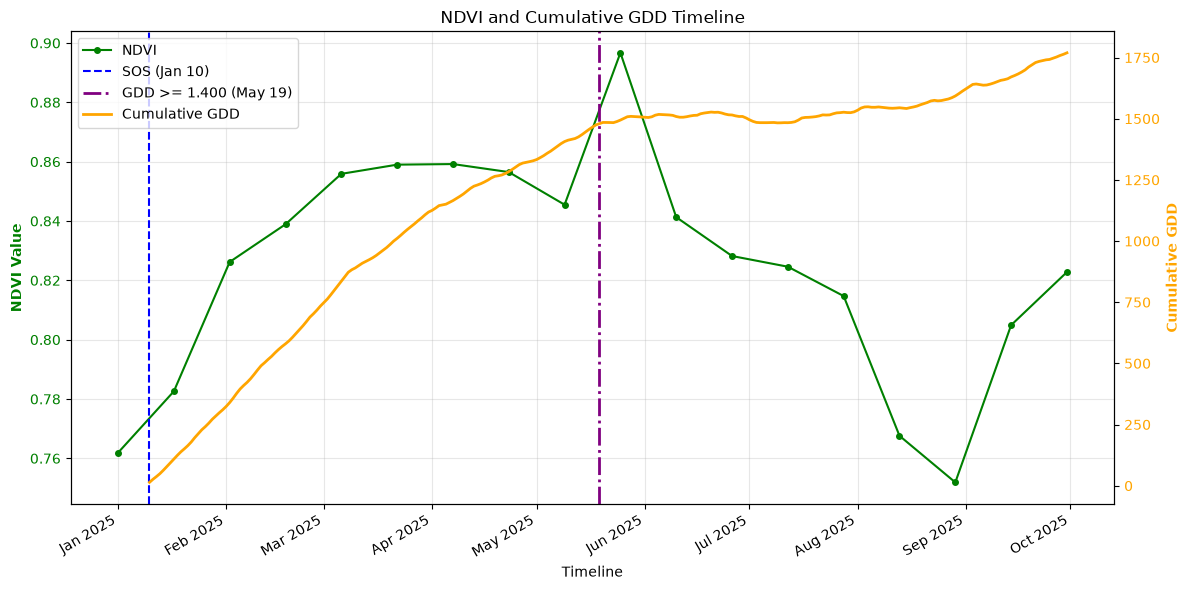

In [51]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

r = clean_df.loc[98]

# 1. Convert NDVI dates to datetime objects (NOT strings)
ndvi_dates = pd.to_datetime(S2_cube["time"].values)

# Scale NDVI values
ndvi_values = [val / 10000 for val in r["ndvi"]]

year = 2025
start_of_year = pd.Timestamp(year=year, month=1, day=1)
sos_date = start_of_year + pd.Timedelta(days=r["sos"] - 1)

if pd.notnull(r["gdd_eos"]):
    gdd_eos_date = sos_date + pd.Timedelta(days=int(r["gdd_eos"]))
else:
    gdd_eos_date = None

gdd_values = r["gdd"]
gdd_dates = pd.date_range(start=sos_date, periods=len(gdd_values), freq="D")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot NDVI
ax1.plot(
    ndvi_dates,
    ndvi_values,
    color="green",
    marker="o",
    markersize=4,
    label="NDVI",
)
ax1.set_xlabel("Timeline")
ax1.set_ylabel("NDVI Value", color="green", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="green")

# Vertical reference lines now align seamlessly
ax1.axvline(
    x=sos_date,
    color="blue",
    linestyle="--",
    label=f'SOS ({sos_date.strftime("%b %d")})',
)

if gdd_eos_date:
    ax1.axvline(
        x=gdd_eos_date,
        color="purple",
        linestyle="-.",
        linewidth=2,
        label=f'GDD >= 1.400 ({gdd_eos_date.strftime("%b %d")})',
    )

# Secondary axis for Cumulative GDD
ax2 = ax1.twinx()
ax2.plot(
    gdd_dates, gdd_values, color="orange", linewidth=2, label="Cumulative GDD"
)
ax2.set_ylabel("Cumulative GDD", color="orange", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="orange")

# Format X-axis date labels cleanly
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

plt.title("NDVI and Cumulative GDD Timeline")
ax1.grid(True, alpha=0.3)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()